# Experiment: VAE Exploration

Objective:
- Train the first-pass VAE on synthetic attack-profile corpora from inside the notebook.
- Inspect convergence, decoded samples, and run artifacts without leaving Jupyter.
- Keep the notebook aligned with the canonical runner in `experiments/train_vae.py`.


## Workflow

This notebook is intentionally split into two modes:
- **Run mode**: launch a training run by calling `run_from_args(...)` from `experiments.train_vae`.
- **Analysis mode**: point at an existing run directory and inspect its metrics, training history, and decoded samples.

Latest run when this notebook was scaffolded:
- `results/runs/vae/20260427_213933_default`


In [1]:
from __future__ import annotations

import json
from argparse import Namespace
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from experiments.train_vae import run_from_args

PROJECT_ROOT = Path.cwd()
PROJECT_ROOT


PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project')

In [2]:
# Config: adjust here before training from the notebook
TRAIN_PATH = Path('data/attack_profiles/synthetic/train_random_v2.jsonl')
VALID_PATH = Path('data/attack_profiles/synthetic/valid_random_v2.jsonl')
RUN_NAME = 'notebook'
SEED = 1945
EPOCHS = 50
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
BETA = 0.05
LATENT_DIM = 4
HIDDEN_DIM = 32
DEVICE = 'auto'
NUM_WORKERS = 0
SAMPLE_COUNT = 16


## Train From Notebook

Run the next cell only when you want to launch a new training job from Jupyter.
It uses the same code path as the terminal script, so the artifacts are identical.


In [ ]:
# Uncomment to launch a fresh run from the notebook
# args = Namespace(
#     train_path=TRAIN_PATH,
#     valid_path=VALID_PATH,
#     output_root=Path('results/runs'),
#     run_name=RUN_NAME,
#     seed=SEED,
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     learning_rate=LEARNING_RATE,
#     beta=BETA,
#     latent_dim=LATENT_DIM,
#     hidden_dim=HIDDEN_DIM,
#     device=DEVICE,
#     num_workers=NUM_WORKERS,
#     sample_count=SAMPLE_COUNT,
# )
# run_dir = run_from_args(args, project_root=PROJECT_ROOT)
# print(run_dir)


## Analysis Setup

Point `RUN_DIR` at an existing VAE training run.
By default it uses the latest run that existed when this notebook was scaffolded.


In [3]:
RUN_DIR = PROJECT_ROOT / 'results/runs/vae/20260427_213933_default'
METRICS_PATH = RUN_DIR / 'metrics_summary.json'
MANIFEST_PATH = RUN_DIR / 'run_manifest.json'
HISTORY_PATH = RUN_DIR / 'training_history.csv'
SAMPLES_PATH = RUN_DIR / 'sampled_profiles.json'

assert RUN_DIR.exists(), RUN_DIR
RUN_DIR


PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/vae/20260427_213933_default')

In [4]:
metrics = json.loads(METRICS_PATH.read_text(encoding='utf-8'))
manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
history = pd.read_csv(HISTORY_PATH)
samples = json.loads(SAMPLES_PATH.read_text(encoding='utf-8'))['profiles']

summary = {
    'train_samples': metrics['dataset']['train_samples'],
    'valid_samples': metrics['dataset']['valid_samples'],
    'latent_dim': metrics['model']['latent_dim'],
    'hidden_dim': metrics['model']['hidden_dim'],
    'parameter_count': metrics['model']['parameter_count'],
    'beta': metrics['model']['beta'],
    'best_epoch': metrics['training']['best_epoch'],
    'best_valid_loss': metrics['training']['best_valid_loss'],
    'final_valid_loss': metrics['training']['final_valid_loss'],
    'device': manifest['device'],
    'total_seconds': metrics['timing']['total_seconds'],
}
summary


{'train_samples': 5000,
 'valid_samples': 1000,
 'latent_dim': 4,
 'hidden_dim': 32,
 'parameter_count': 3088,
 'beta': 0.05,
 'best_epoch': 50,
 'best_valid_loss': 0.40725259855389595,
 'final_valid_loss': 0.40725259855389595,
 'device': 'mps',
 'total_seconds': 12.944703459041193}

In [5]:
history.tail()


,epoch,train_loss,train_recon_loss,train_kl_loss,valid_loss,valid_recon_loss,valid_kl_loss
45,46,0.409288,0.160290,4.979958,0.409891,0.164754,4.902743
46,47,0.410279,0.162011,4.965367,0.410746,0.161923,4.976459
47,48,0.406209,0.157710,4.969995,0.412689,0.164664,4.960498
48,49,0.409128,0.160378,4.974986,0.411643,0.161197,5.008915
49,50,0.406861,0.156772,5.001795,0.407253,0.162013,4.904783


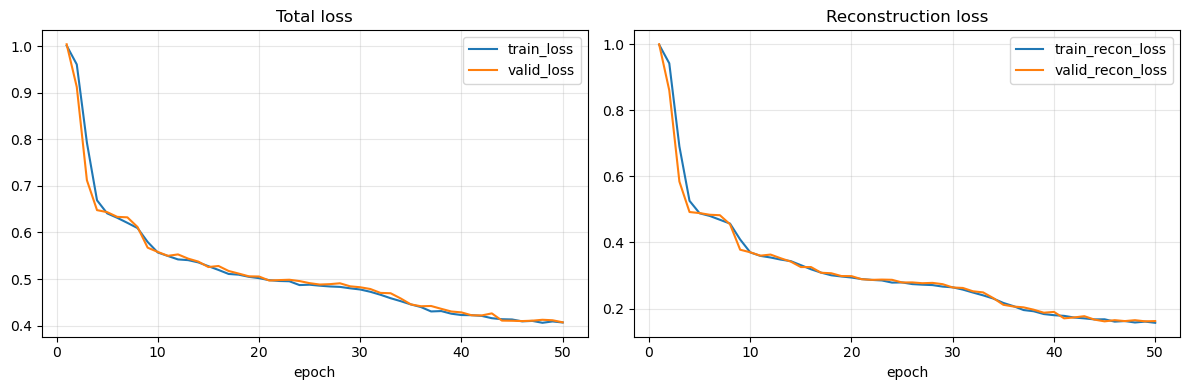

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history.plot(x='epoch', y=['train_loss', 'valid_loss'], ax=axes[0], title='Total loss')
history.plot(x='epoch', y=['train_recon_loss', 'valid_recon_loss'], ax=axes[1], title='Reconstruction loss')
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


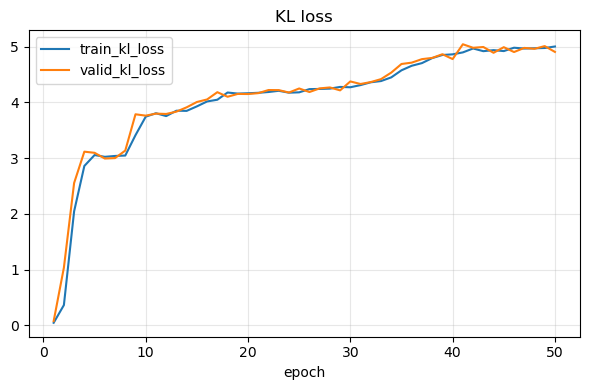

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
history.plot(x='epoch', y=['train_kl_loss', 'valid_kl_loss'], ax=ax, title='KL loss')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Decoded Sample Inspection

These are latent-prior samples decoded directly through the VAE and saved by the training script.
They are not yet rechecked by the feasibility/audit pipeline.


In [8]:
samples_df = pd.DataFrame(samples)
samples_df[['profile_id', 'u_pos', 'base_bearing_rad', 'spread_rad', 'launch_delay_s', 'salvo_interval_s', 'u_boat_initial_speed_mps']].head(10)


,profile_id,u_pos,base_bearing_rad,spread_rad,launch_delay_s,salvo_interval_s,u_boat_initial_speed_mps
0,VAE_SAMPLE_0001,"[-947.7807006835938, 1926.8245849609375]",-1.137039,0.107635,2.258802,1.754332,1.379737
1,VAE_SAMPLE_0002,"[1675.76513671875, 677.741455078125]",-2.818812,0.113369,3.137887,2.376405,1.414524
2,VAE_SAMPLE_0003,"[-1211.629638671875, -1933.0164794921875]",1.030507,0.283092,2.376021,2.985550,1.454996
3,VAE_SAMPLE_0004,"[1308.2032470703125, 1680.6220703125]",-2.245328,0.098412,0.937765,1.719915,1.770451
4,VAE_SAMPLE_0005,"[-2396.117919921875, -223.2628173828125]",0.099869,0.091548,1.684171,2.913359,1.764124
5,VAE_SAMPLE_0006,"[1691.48095703125, 215.42535400390625]",-3.017372,0.097237,2.367764,2.275432,1.866027
6,VAE_SAMPLE_0007,"[2035.7984619140625, -204.14268493652344]",2.999978,0.105274,1.135624,1.733613,1.921024
7,VAE_SAMPLE_0008,"[-2008.2469482421875, 620.3154296875]",-0.412891,0.237716,1.009824,2.079577,1.550117
8,VAE_SAMPLE_0009,"[171.76913452148438, -1379.8656005859375]",1.690953,0.093736,0.577780,2.346625,1.976655
9,VAE_SAMPLE_0010,"[1184.3560791015625, 1780.167236328125]",-2.160072,0.090598,0.467748,2.538430,1.798983


In [9]:
samples_df[['spread_rad', 'launch_delay_s', 'salvo_interval_s', 'u_boat_initial_speed_mps']].describe()


,spread_rad,launch_delay_s,salvo_interval_s,u_boat_initial_speed_mps
count,16.000000,16.000000,16.000000,16.000000
mean,0.158401,1.500994,2.126644,1.629086
std,0.071039,0.750758,0.490085,0.292958
min,0.090598,0.467748,1.508757,1.117668
25%,0.098119,0.960050,1.716577,1.405827
50%,0.118892,1.367530,1.966739,1.657121
75%,0.220305,2.075224,2.416911,1.879776
max,0.283092,3.137887,2.985550,2.000000


## Notes

Initial read on the scaffolded reference run:
- validation loss was still improving at epoch 50
- no obvious instability in KL or reconstruction terms
- decoded samples look numerically reasonable, but still need post-decode feasibility and audit gating


## Next Steps

- Add a notebook cell that loads `checkpoints/model_best.pt` and samples directly from the checkpoint.
- Add post-decode feasibility + audit filtering for VAE-generated profiles.
- Compare generated-sample distributions against the source dataset audit outputs.
